<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:28px;
">
Tres ejercicios de regresión lineal con ML
</h2>

</div>

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:28px;
">
Ejercicio 2: Agujeros Negros Supermasivos
</h2>

</div>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:


rows = []

with open("table1.dat", "r") as f:
    for line in f:
        tokens = line.split()

        for i, t in enumerate(tokens):
            try:
                val = float(t)
                if 0 <= val < 1:
                    idx = i
                    break
            except:
                pass

        name = " ".join(tokens[:idx])

        values = []
        flag = None

        for t in tokens[idx:]:
            if t in ["a", "b"]:
                flag = t
            else:
                try:
                    values.append(float(t))
                except:
                    pass

        z = values[0]
        sigma = values[1]
        e_sigma = values[2]

        FWHM = np.nan
        e_FWHM = np.nan
        logL_Ha = np.nan
        e_logL_Ha = np.nan
        logMBH = np.nan
        e_logMBH = np.nan

        rest = values[3:]

        if len(rest) >= 6:
            FWHM = rest[0]
            e_FWHM = rest[1]
            logL_Ha = rest[2]
            e_logL_Ha = rest[3]
            logMBH = rest[4]
            e_logMBH = rest[5]
        elif len(rest) >= 2:
            logMBH = rest[0]
            e_logMBH = rest[1]

        rows.append([
            name, z, sigma, e_sigma, flag,
            FWHM, e_FWHM, logL_Ha, e_logL_Ha,
            logMBH, e_logMBH
        ])

df = pd.DataFrame(rows, columns=[
    "name", "z", "sigma", "e_sigma", "flag",
    "FWHM", "e_FWHM", "logL_Ha", "e_logL_Ha",
    "logMBH", "e_logMBH"
])

df.head()

,name,z,sigma,e_sigma,flag,FWHM,e_FWHM,logL_Ha,e_logL_Ha,logMBH,e_logMBH
0,SDSS J000805.62+145023.4,0.0454,140.0,27.0,NaN,7610.0,380.0,41.13,0.04,7.7,0.1
1,SDSS J004236.86-104921.8,0.0419,78.4,10.0,NaN,1960.0,97.0,41.58,0.14,6.7,0.1
2,SDSS J011703.58+000027.3,0.0456,98.8,16.0,NaN,2270.0,110.0,41.45,0.08,6.8,0.1
3,SDSS J020459.25-080816.0,0.0772,121.0,9.4,a,3720.0,180.0,41.13,0.05,7.0,0.1
4,SDSS J020615.99-001729.1,0.0426,216.0,30.0,NaN,3860.0,190.0,41.91,0.07,7.5,0.1


In [5]:
#model sig

x = np.log10(df["sigma"] / 200)
y = df["logMBH"]

theta1, theta0 = np.polyfit(x, y, 1)

y_pred = theta1*x + theta0

ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot

print("Modelo con sigma")
print("theta0 =", theta0)
print("theta1 =", theta1)
print("R² =", r2)

Modelo con sigma
theta0 = 7.662569577689883
theta1 = 2.9254290088343904
R² = 0.6187769871433767


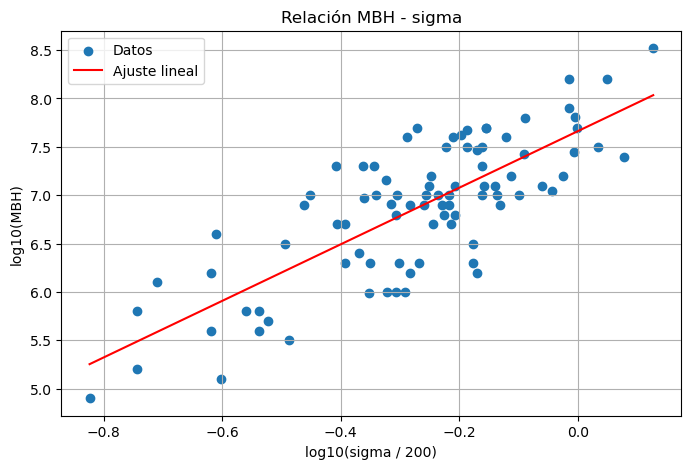

In [6]:
plt.figure(figsize=(8,5))

plt.scatter(x, y, label="Datos")

x_line = np.linspace(min(x), max(x), 100)
y_line = theta1*x_line + theta0

plt.plot(x_line, y_line, color="red", label="Ajuste lineal")

plt.xlabel("log10(sigma / 200)")
plt.ylabel("log10(MBH)")
plt.title("Relación MBH - sigma")
plt.grid(True)
plt.legend()
plt.show()

In [7]:
#regre FWHM

df_fwhm = df.dropna(subset=["FWHM"])

x = np.log10(df_fwhm["FWHM"])
y = df_fwhm["logMBH"]

theta1, theta0 = np.polyfit(x, y, 1)

y_pred = theta1*x + theta0

ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res/ss_tot

print("Modelo con FWHM")
print("theta0 =", theta0)
print("theta1 =", theta1)
print("R² =", r2)

Modelo con FWHM
theta0 = -1.6821747021716962
theta1 = 2.4707627756770263
R² = 0.8472284869342417


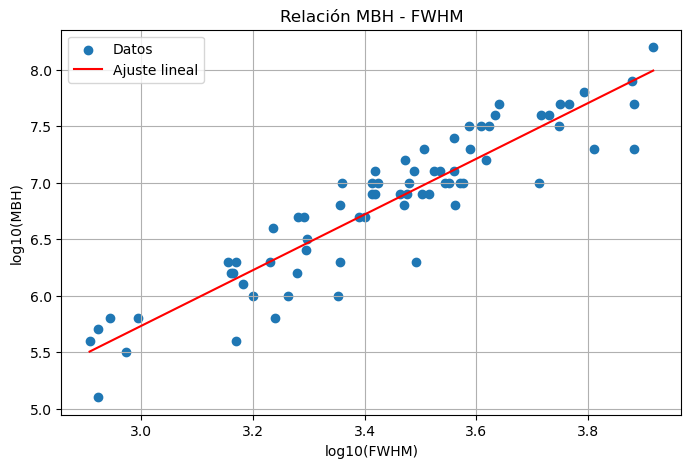

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(x, y, label="Datos")

x_line = np.linspace(min(x), max(x), 100)
y_line = theta1*x_line + theta0

plt.plot(x_line, y_line, color="red", label="Ajuste lineal")

plt.xlabel("log10(FWHM)")
plt.ylabel("log10(MBH)")
plt.title("Relación MBH - FWHM")
plt.grid(True)
plt.legend()
plt.show()

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Ejercicio 2: Agujeros Negros Supermasivos
</h3>

<p>
Se utilizó el archivo <code>table1.dat</code>, que contiene información observacional de AGNs.
</p>

<p>
Se estudiaron dos relaciones:
</p>

$$
\log(M_{BH}) = \theta_0 + \theta_1 \log(\sigma/200)
$$

<p>
y
</p>

$$
\log(M_{BH}) = \theta_0 + \theta_1 \log(FWHM)
$$

<p>
Para el segundo caso se eliminaron las filas con valores faltantes de FWHM.
</p>

<p>
Los resultados muestran una correlación positiva entre la masa del agujero negro y ambas variables observacionales.
</p>

<p>
El ajuste usando FWHM produjo:
</p>

<ul>
<li>θ₀ = -1.682</li>
<li>θ₁ = 2.471</li>
<li>R² = 0.847</li>
</ul>

<p>
lo que indica que el modelo explica aproximadamente el 84.7% de la variabilidad observada en la masa del agujero negro.
</p>

<p>
Las gráficas muestran que a mayores valores de σ y FWHM corresponden agujeros negros más masivos, en concordancia con los resultados reportados en la literatura.
</p>

</div>

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:28px;
">
Ejercicio 03: Multilineal + Ridge + Lasso
</h2>

</div>

In [10]:
#solo preparo mis datos
import numpy as np
import pandas as pd

df_ml = df.dropna(subset=["sigma","FWHM","logMBH"]).copy()

X1 = np.log10(df_ml["sigma"])
X2 = np.log10(df_ml["FWHM"])

y = df_ml["logMBH"]

X = np.column_stack((X1,X2))

In [11]:
#regre multil
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X,y)

print("Intercepto =", modelo.intercept_)
print("Coef sigma =", modelo.coef_[0])
print("Coef FWHM =", modelo.coef_[1])

r2 = modelo.score(X,y)

print("R² =", r2)

Intercepto = -1.968937323341926
Coef sigma = 0.7615756591251165
Coef FWHM = 2.108130544067966
R² = 0.8706001699679848


In [12]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X,y)

print("Intercepto =", ridge.intercept_)
print("Coef sigma =", ridge.coef_[0])
print("Coef FWHM =", ridge.coef_[1])

r2_ridge = ridge.score(X,y)

print("R² =", r2_ridge)

Intercepto = -0.599081496580883
Coef sigma = 0.7825615509621933
Coef FWHM = 1.6977432099181005
R² = 0.8483331898494754


In [13]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)

lasso.fit(X,y)

print("Intercepto =", lasso.intercept_)
print("Coef sigma =", lasso.coef_[0])
print("Coef FWHM =", lasso.coef_[1])

r2_lasso = lasso.score(X,y)

print("R² =", r2_lasso)

Intercepto = -1.2790409772607259
Coef sigma = 0.4595748738536643
Coef FWHM = 2.0844854333496716
R² = 0.8630337405030034


In [14]:
#comparación
print("OLS   :", r2)
print("Ridge :", r2_ridge)
print("Lasso :", r2_lasso)

OLS   : 0.8706001699679848
Ridge : 0.8483331898494754
Lasso : 0.8630337405030034


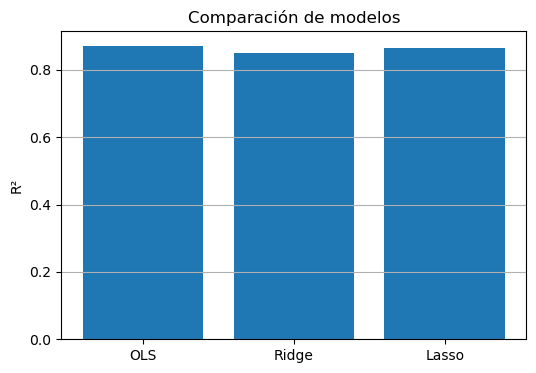

In [15]:
import matplotlib.pyplot as plt

modelos = ["OLS","Ridge","Lasso"]
scores = [r2,r2_ridge,r2_lasso]

plt.figure(figsize=(6,4))
plt.bar(modelos,scores)

plt.ylabel("R²")
plt.title("Comparación de modelos")
plt.grid(axis="y")

plt.show()

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Discusión
</h3>

<p>
Se compararon tres modelos de regresión para estimar la masa del agujero negro supermasivo utilizando simultáneamente las variables <code>log(σ)</code> y <code>log(FWHM)</code>.
</p>

<p>
Los resultados muestran que los tres modelos presentan valores de <code>R²</code> similares, cercanos a 0.85–0.87, indicando que ambas variables contienen información relevante sobre la masa del agujero negro.
</p>

<p>
La regularización Ridge y Lasso no produjeron mejoras significativas respecto a la regresión lineal múltiple tradicional, lo que sugiere que el conjunto de variables utilizado no presenta problemas severos de sobreajuste o multicolinealidad.
</p>

<p>
En general, la relación entre la masa del agujero negro y las propiedades observacionales de los AGNs puede describirse adecuadamente mediante un modelo lineal.
</p>

</div>

<div style="
background-color:#ffe6f0;
padding:24px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h2 style="
margin-top:0;
color:#c2185b;
font-size:28px;
">
Supernovas y Cosmología
</h2>

</div>

In [18]:
import pandas as pd

data = pd.read_csv("data_sample (1).csv")

print(data.head())

   z_sample  mu_sample
0  0.574163  43.691174
1  0.739362  42.250323
2  0.622291  41.734378
3  0.570798  42.185804
4  0.473621  41.642052


In [19]:
z = data["z_sample"].values
mu = data["mu_sample"].values

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    z.reshape(-1,1),
    mu,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()

modelo.fit(X_train, y_train)

r2 = modelo.score(X_test, y_test)

print("Pendiente =", modelo.coef_[0])
print("Intercepto =", modelo.intercept_)
print("R² =", r2)

Pendiente = 3.945164100184694
Intercepto = 39.895702621998254
R² = 0.6497255059795124


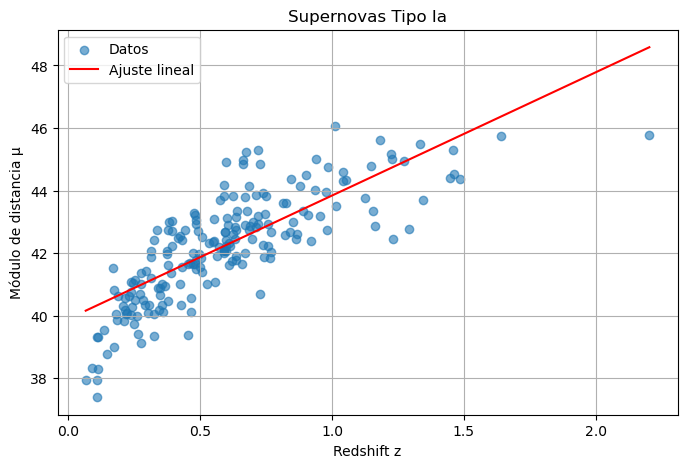

In [22]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))

plt.scatter(z, mu, alpha=0.6, label="Datos")

z_line = np.linspace(min(z), max(z), 200)

mu_line = modelo.predict(z_line.reshape(-1,1))

plt.plot(z_line, mu_line,
         color="red",
         label="Ajuste lineal")

plt.xlabel("Redshift z")
plt.ylabel("Módulo de distancia μ")
plt.title("Supernovas Tipo Ia")
plt.grid(True)
plt.legend()

plt.show()

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Interpretación de la primera gráfica
</h3>

<p>
La gráfica de Supernovas Tipo Ia muestra que:
</p>

<ul>
<li>A medida que aumenta el redshift <code>z</code>, aumenta el módulo de distancia <code>μ</code>.</li>
<li>Los datos siguen una tendencia creciente.</li>
<li>Existe dispersión alrededor de la recta.</li>
<li>La relación real es ligeramente curva, por lo que una recta no captura completamente el comportamiento cosmológico.</li>
</ul>

<p>
Por eso el coeficiente de determinación <code>R²</code> no es cercano a 1.
</p>

</div>

In [23]:
#variación del tama;o 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

sizes = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]

scores = []

for s in sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        z.reshape(-1,1),
        mu,
        train_size=s,
        random_state=42
    )

    modelo = LinearRegression()
    modelo.fit(X_train,y_train)

    scores.append(modelo.score(X_test,y_test))

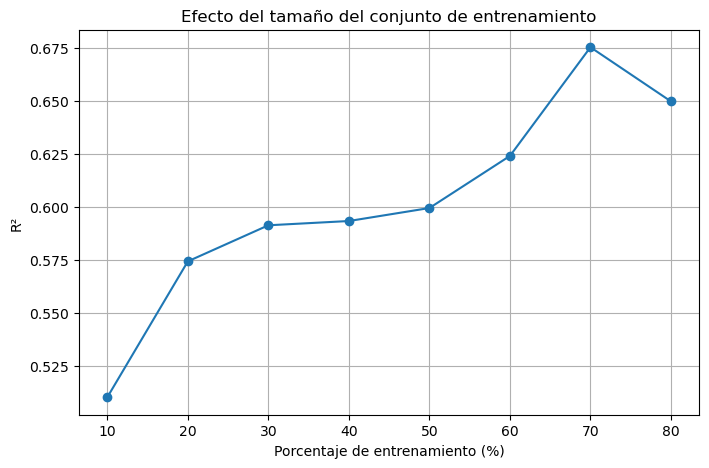

In [24]:
plt.figure(figsize=(8,5))

plt.plot(
    np.array(sizes)*100,
    scores,
    marker="o"
)

plt.xlabel("Porcentaje de entrenamiento (%)")
plt.ylabel("R²")
plt.title("Efecto del tamaño del conjunto de entrenamiento")

plt.grid(True)

plt.show()

<div style="
background-color:#ffe6f0;
padding:22px;
border-radius:16px;
border:1.5px solid #ffb3d1;
color:#1a1a1a;
font-size:16px;
line-height:1.8;
">

<h3 style="
margin-top:0;
color:#c2185b;
font-size:26px;
">
Interpretación de la segunda gráfica
</h3>

<p>
La gráfica del tamaño del conjunto de entrenamiento muestra:
</p>

<ul>
<li>Con pocos datos (10%) el modelo tiene menor capacidad predictiva.</li>
<li>Al aumentar el tamaño del conjunto de entrenamiento, el valor de <code>R²</code> mejora.</li>
<li>El mejor desempeño se alcanza alrededor del 70% de entrenamiento.</li>
<li>Después de ese punto las variaciones son pequeñas, indicando que el modelo ya aprendió la tendencia principal de los datos.</li>
</ul>

</div>